# Aufgabe 5

In [8]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

In [ ]:
ty_img = imread("tv.png")

## 5.1

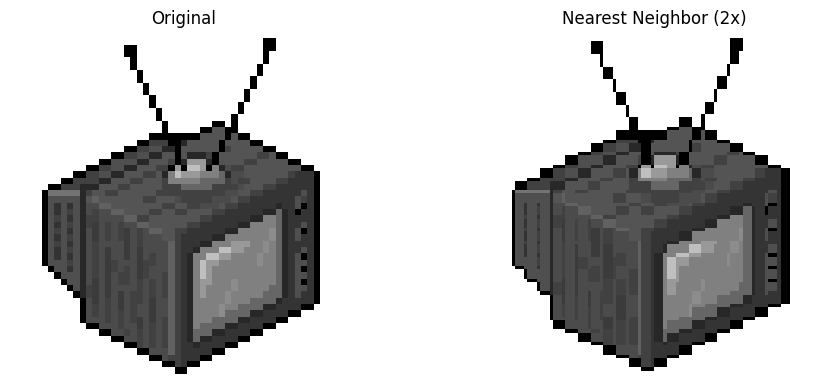

Original: (55, 55) → Nearest Neighbor (2x): (110, 110)


In [12]:
def scale_image_nearest_neighbor(image, scale_factor):
    """Skaliert ein Bild mit nearest neighbor Interpolation (inverse mapping)."""
    h, w = image.shape[:2]
    new_h, new_w = int(np.round(h * scale_factor)), int(np.round(w * scale_factor))
    
    # Output-Bild erstellen
    if len(image.shape) == 3:
        output = np.zeros((new_h, new_w, image.shape[2]), dtype=image.dtype)
    else:
        output = np.zeros((new_h, new_w), dtype=image.dtype)
    
    # Inverse mapping: für jeden Pixel im Output berechne Quelle im Input
    for y_out in range(new_h):
        for x_out in range(new_w):
            x_in = np.clip(int(np.round(x_out / scale_factor)), 0, w - 1)
            y_in = np.clip(int(np.round(y_out / scale_factor)), 0, h - 1)
            output[y_out, x_out] = image[y_in, x_in]
    
    return output

# Test 5.1: Nearest Neighbor
tv_img = imread('tv.png')
scaled_nn = scale_image_nearest_neighbor(tv_img, 2.0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(tv_img, cmap="gray")
plt.title("Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(scaled_nn, cmap="gray")
plt.title("Nearest Neighbor (2x)")
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Original: {tv_img.shape} → Nearest Neighbor (2x): {scaled_nn.shape}")

## 5.2

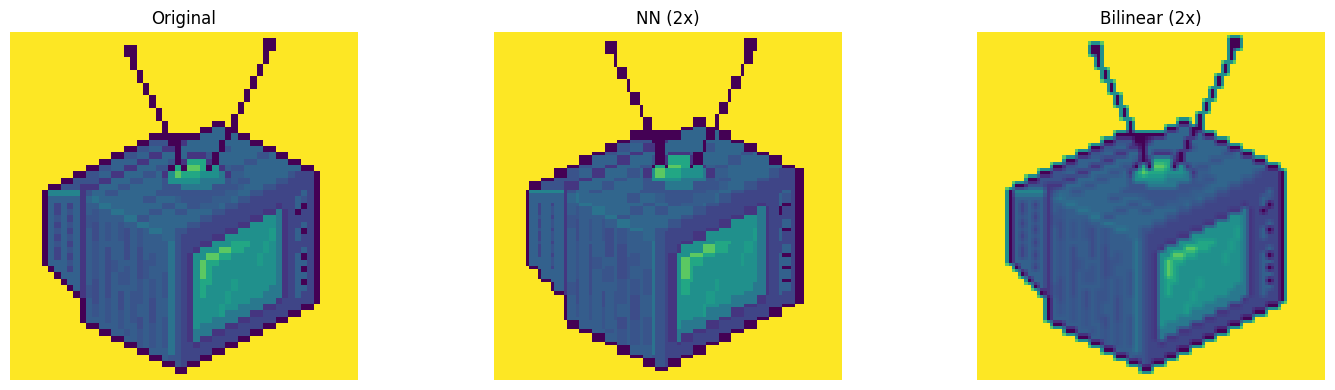

Vergleich: Nearest Neighbor vs. Bilinear (beide 2x)
  NN:      uint8 (110, 110)
  Bilinear: uint8 (110, 110)


In [10]:
def scale_image_bilinear(image, scale_factor):
    """Skaliert ein Bild mit bilinearer Interpolation (inverse mapping)."""
    h, w = image.shape[:2]
    new_h, new_w = int(np.round(h * scale_factor)), int(np.round(w * scale_factor))
    
    if len(image.shape) == 3:
        output = np.zeros((new_h, new_w, image.shape[2]), dtype=np.float32)
    else:
        output = np.zeros((new_h, new_w), dtype=np.float32)
    
    # Inverse mapping mit bilinearer Interpolation
    for y_out in range(new_h):
        for x_out in range(new_w):
            x_in = x_out / scale_factor
            y_in = y_out / scale_factor
            
            # Vier umliegende Pixel und Gewichte
            x0, x1 = int(np.floor(x_in)), int(np.ceil(x_in))
            y0, y1 = int(np.floor(y_in)), int(np.ceil(y_in))
            
            x0, x1 = np.clip([x0, x1], 0, w - 1)
            y0, y1 = np.clip([y0, y1], 0, h - 1)
            
            wx = x_in - np.floor(x_in)
            wy = y_in - np.floor(y_in)
            
            # Bilineare Interpolation
            f0 = image[y0, x0] * (1 - wx) + image[y0, x1] * wx
            f1 = image[y1, x0] * (1 - wx) + image[y1, x1] * wx
            output[y_out, x_out] = f0 * (1 - wy) + f1 * wy
    
    return output.astype(image.dtype)

# Test 5.2: Bilinear Interpolation
scaled_bl = scale_image_bilinear(tv_img, 2.0)

plt.figure(figsize=(15, 4))
for i, (img, title) in enumerate([(tv_img, "Original"), (scaled_nn, "NN (2x)"), (scaled_bl, "Bilinear (2x)")]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Vergleich: Nearest Neighbor vs. Bilinear (beide 2x)")
print(f"  NN:      {scaled_nn.dtype} {scaled_nn.shape}")
print(f"  Bilinear: {scaled_bl.dtype} {scaled_bl.shape}")

## 5.3 - Analyse: Details bei Vergrößerung und Rückgängigmachen von Skalierung

FRAGE 1: Werden Details des Fernsehers gewonnen bei Vergrößerung (s > 1)?

ANTWORT: NEIN. Bei Upscaling werden KEINE neuen Details gewonnen:
- Nearest Neighbor: Wiederholt Pixel → blocky Artefakte
- Bilinear: Interpoliert zwischen Pixeln → glatteres, aber nicht detaillierter
Grundprinzip: Man kann keine Information hinzufügen, die nicht vorhanden ist!

Beispiel: (55, 55) × 2 = (110, 110)
→ Größer, aber nicht detaillierter

FRAGE 2: Verkleinerung (0.5x) + Vergrößerung (2x) = Original?

ANTWORT: NEIN. Dieser Prozess ist NICHT reversibel:
- Verkleinerung: Informationen gehen verloren (mehrere Pixel → ein Pixel)
- Vergrößerung: Kann verlorene Info nicht wiederherstellen
- Resultat: Unschärfer und weniger Details als Original

Original:        (55, 55)
Nach 0.5x:       (28, 28)
Nach 2x zurück:  (56, 56)
Mittl. Abweichung zum Original: 13.3
→ Deutlicher Unterschied - Informationen permanent verloren!



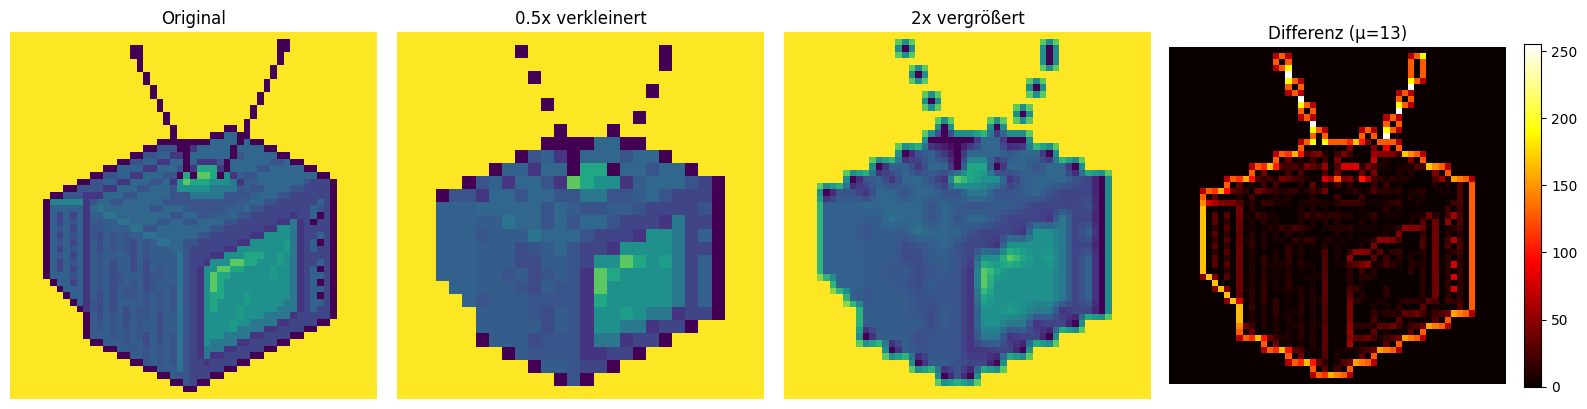

FAZIT

1. Vergrößerung (s > 1): Keine neuen Details, nur Interpolation
2. Verkleinerung + Vergrößerung: Nicht reversibel, Informationsverlust
3. Fundamentales Prinzip: Information kann nicht aus nichts entstehen!



In [11]:
# Test 5.3: Analysefragen
print("="*70)
print("FRAGE 1: Werden Details des Fernsehers gewonnen bei Vergrößerung (s > 1)?")
print("="*70)
print("""
ANTWORT: NEIN. Bei Upscaling werden KEINE neuen Details gewonnen:
- Nearest Neighbor: Wiederholt Pixel → blocky Artefakte
- Bilinear: Interpoliert zwischen Pixeln → glatteres, aber nicht detaillierter
Grundprinzip: Man kann keine Information hinzufügen, die nicht vorhanden ist!
""")

scaled_up = scale_image_bilinear(tv_img, 2.0)
print(f"Beispiel: {tv_img.shape} × 2 = {scaled_up.shape}")
print("→ Größer, aber nicht detaillierter\n")

print("="*70)
print("FRAGE 2: Verkleinerung (0.5x) + Vergrößerung (2x) = Original?")
print("="*70)
print("""
ANTWORT: NEIN. Dieser Prozess ist NICHT reversibel:
- Verkleinerung: Informationen gehen verloren (mehrere Pixel → ein Pixel)
- Vergrößerung: Kann verlorene Info nicht wiederherstellen
- Resultat: Unschärfer und weniger Details als Original
""")

# Verkleinerung und Vergrößerung
scaled_down = scale_image_bilinear(tv_img, 0.5)
scaled_back = scale_image_bilinear(scaled_down, 2.0)

# Crop auf gleiche Größe wegen Rounding-Effekten
min_h = min(tv_img.shape[0], scaled_back.shape[0])
min_w = min(tv_img.shape[1], scaled_back.shape[1])
tv_crop = tv_img[:min_h, :min_w]
scaled_crop = scaled_back[:min_h, :min_w]

diff = np.abs(tv_crop.astype(np.float32) - scaled_crop.astype(np.float32))
mean_diff = np.mean(diff)

print(f"Original:        {tv_img.shape}")
print(f"Nach 0.5x:       {scaled_down.shape}")
print(f"Nach 2x zurück:  {scaled_back.shape}")
print(f"Mittl. Abweichung zum Original: {mean_diff:.1f}")
print("→ Deutlicher Unterschied - Informationen permanent verloren!\n")

# Visualisierung
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(tv_img), axes[0].set_title("Original"), axes[0].axis('off')
axes[1].imshow(scaled_down), axes[1].set_title("0.5x verkleinert"), axes[1].axis('off')
axes[2].imshow(scaled_back), axes[2].set_title("2x vergrößert"), axes[2].axis('off')
im = axes[3].imshow(diff, cmap='hot')
axes[3].set_title(f"Differenz (μ={mean_diff:.0f})")
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046)
plt.tight_layout()
plt.show()

print("="*70)
print("FAZIT")
print("="*70)
print("""
1. Vergrößerung (s > 1): Keine neuen Details, nur Interpolation
2. Verkleinerung + Vergrößerung: Nicht reversibel, Informationsverlust
3. Fundamentales Prinzip: Information kann nicht aus nichts entstehen!
""")